In [1]:
import numpy as np

In [2]:
# read compressed-trotter
data_dir = './dimer/perth/trotters/compressed/'
nU_compress = 11
Us_compress = np.zeros((nU_compress),dtype=float)
E_perth_compress = np.zeros(nU_compress,dtype=float)
with open(data_dir +'/perth/dimer.qzmc.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Us_compress[iU] = float(ls[0])
        E_perth_compress[iU] = float(ls[1])
        iU += 1

E_qasm_compress = np.zeros((nU_compress),dtype=float)
with open(data_dir + '/qasm/dimer.qzmc.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        E_qasm_compress[iU] = float(ls[1])
        iU += 1

norms_perth_compress = np.zeros(nU_compress,dtype=float)
with open(data_dir +'/perth/dimer.qzmc.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        norms_perth_compress[iU] = float(ls[1])
        iU += 1

norms_qasm_compress = np.zeros((nU_compress),dtype=float)
with open(data_dir + '/qasm/dimer.qzmc.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        norms_qasm_compress[iU] = float(ls[1])
        iU += 1

norms_exact_compress = np.zeros((nU_compress), dtype=float)
with open(data_dir+'./qasm/dimer.exact.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        norms_exact_compress[iU] = float(ls[1])
        iU += 1

nU_fine = 101
Us_fine = np.zeros((nU_fine),dtype=float)
E_fine = np.zeros(nU_fine,dtype=float)
with open('./dimer/perth/dimer.fine.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Us_fine[iU] = float(ls[0])
        E_fine[iU] = float(ls[1])
        iU += 1

In [3]:
# read naive-trotter
data_dir = './dimer/perth/trotters/naive/'
nU_naive = 5
Us_naive = np.zeros((nU_naive),dtype=float)
E_perth_naive = np.zeros(nU_naive,dtype=float)
with open(data_dir +'/perth/dimer.qzmc.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        Us_naive[iU] = float(ls[0])
        E_perth_naive[iU] = float(ls[1])
        iU += 1

E_qasm_naive = np.zeros((nU_naive),dtype=float)
with open(data_dir + '/qasm/dimer.qzmc.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        E_qasm_naive[iU] = float(ls[1])
        iU += 1

norms_perth_naive = np.zeros(nU_naive,dtype=float)
with open(data_dir +'/perth/dimer.qzmc.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        norms_perth_naive[iU] = float(ls[1])
        iU += 1

norms_qasm_naive = np.zeros((nU_naive),dtype=float)
with open(data_dir + '/qasm/dimer.qzmc.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        norms_qasm_naive[iU] = float(ls[1])
        iU += 1

norms_exact_naive = np.zeros((nU_naive), dtype=float)
with open(data_dir+'./qasm/dimer.exact.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        norms_exact_naive[iU] = float(ls[1])
        iU += 1

E_perth_naive_woid = np.zeros(nU_naive,dtype=float)
with open(data_dir +'/perth-wo-id/dimer.qzmc.energies','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        E_perth_naive_woid[iU] = float(ls[1])
        iU += 1

norms_perth_naive_woid = np.zeros(nU_naive,dtype=float)
with open(data_dir +'/perth-wo-id/dimer.qzmc.norms','r') as file_:
    iU = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        norms_perth_naive_woid[iU] = float(ls[1])
        iU += 1


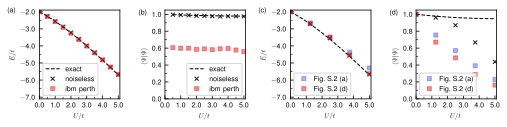

In [4]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size"  : 7
})

cm    = 1.0/2.54
width = 18*cm 
height = 18/4*cm 
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',linewidth=1.0, color='black')
marker_style_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.5,  fillstyle='full')
marker_style_2  = dict(marker='s', linestyle='none', color='mediumblue', alpha=0.3,  fillstyle='full')
marker_style_3  = dict(marker='x', linestyle='none', color='black', alpha=0.9,  fillstyle='full')


axes = []
ax = plt.subplot2grid((1,4),(0,0))
axes.append(ax)
ax = plt.subplot2grid((1,4),(0,1))
axes.append(ax)
ax = plt.subplot2grid((1,4),(0,2))
axes.append(ax)
ax = plt.subplot2grid((1,4),(0,3))
axes.append(ax)

# (a) compressed, n_trotter=4

axis = axes[0]

y_min    =  -7.1
y_max    =  -1.9
#
x_min    =  0
x_max    =  5.1

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.40,0.975,r'(a)',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
axis.set_xlabel(r'$U/t$')
axis.set_ylabel(r'$E/t$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
axis.plot(Us_fine,E_fine, label='exact', **marker_style_ref)
axis.plot(Us_compress,E_qasm_compress, label ='noiseless', markersize=4, **marker_style_3)
axis.plot(Us_compress,E_perth_compress, label ='ibm_perth', markersize=4, **marker_style_1)

axis.legend(loc='lower left')

# (b) norms

axis = axes[1]

y_min    = 0.0
y_max    = 1.05

x_min    =  0
x_max    =  5.1

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.33,0.95,r'(b)',transform=axis.transAxes)
axis.set_xlabel(r'$U/t$')
axis.set_ylabel(r'$\langle{\Psi|\Psi\rangle}$')
#axis.text(0.5,-0.2,r'$U/t$',transform=axis.transAxes)
#axis.text(-0.28,0.5,r'$||\Psi||^2$',transform=axis.transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axis.plot(Us_compress[1:],norms_exact_compress[1:], label='exact', **marker_style_ref)
axis.plot(Us_compress[1:],norms_qasm_compress[1:], label ='noiseless', markersize=4, **marker_style_3)
axis.plot(Us_compress[1:],norms_perth_compress[1:], label ='ibm_perth', markersize=4, **marker_style_1)


axis.legend(loc='lower right')
#
#
# (c) naive, n_trotter=1

axis = axes[2]

y_min    =  -7.1
y_max    =  -1.9
#
x_min    =  0
x_max    =  5.1

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
#axes[0].text(-0.25,0.98,'(a)',transform=axes[0].transAxes)
axis.text(-0.40,0.975,r'(c)',transform=axis.transAxes)
#axes[0].text(0.5,-0.2,r'$R(\AA)$',transform=axes[0].transAxes)
axis.set_xlabel(r'$U/t$')
axis.set_ylabel(r'$E/t$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
axis.plot(Us_fine,E_fine, label='', **marker_style_ref)
axis.plot(Us_naive,E_qasm_naive, label ='', markersize=4, **marker_style_3)
#axis.plot(Us_naive,E_perth_naive_woid, label =r'Fig.~8~(a)', markersize=4, **marker_style_2)
#axis.plot(Us_naive,E_perth_naive, label =r'Fig.~8~(d)', markersize=4, **marker_style_1)
axis.plot(Us_naive,E_perth_naive_woid, label =r'Fig.~S.2~(a)', markersize=4, **marker_style_2)
axis.plot(Us_naive,E_perth_naive, label =r'Fig.~S.2~(d)', markersize=4, **marker_style_1)

axis.legend(handletextpad=0.4,loc='lower left')

# (d) norms

axis = axes[3]

y_min    = 0.0
y_max    = 1.05

x_min    =  0
x_max    =  5.1

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.33,0.95,r'(d)',transform=axis.transAxes)
axis.set_xlabel(r'$U/t$')
axis.set_ylabel(r'$\langle{\Psi|\Psi\rangle}$')
#axis.text(0.5,-0.2,r'$U/t$',transform=axis.transAxes)
#axis.text(-0.28,0.5,r'$||\Psi||^2$',transform=axis.transAxes)
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(1))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axis.plot(Us_naive[0:],norms_exact_naive[0:], label='', **marker_style_ref)
axis.plot(Us_naive[0:],norms_qasm_naive[0:], label ='', markersize=4, **marker_style_3)
#axis.plot(Us_naive[0:],norms_perth_naive_woid[0:], label =r'Fig.~8~(a)', markersize=4, **marker_style_2)
#axis.plot(Us_naive[0:],norms_perth_naive[0:], label =r'Fig.~8~(d)', markersize=4, **marker_style_1)
axis.plot(Us_naive[0:],norms_perth_naive_woid[0:], label =r'Fig.~S.2~(a)', markersize=4, **marker_style_2)
axis.plot(Us_naive[0:],norms_perth_naive[0:], label =r'Fig.~S.2~(d)', markersize=4, **marker_style_1)


axis.legend(handletextpad=0.4,loc='lower left')
#
#
#
plt.tight_layout()
plt.savefig('figS6.pdf')
#